In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
np.random.seed(2025)

In [3]:
# generating the training data. 
# data group 1: mu1 = 3, sigma1 = 1
mu1 = 3
sigma1 = 1

# data group 2: mu2 = 7, sigma2 = 2.5 
mu2 = 7
sigma2 = 2.5

num = 500

Text(0.5, 1.0, 'ground truth')

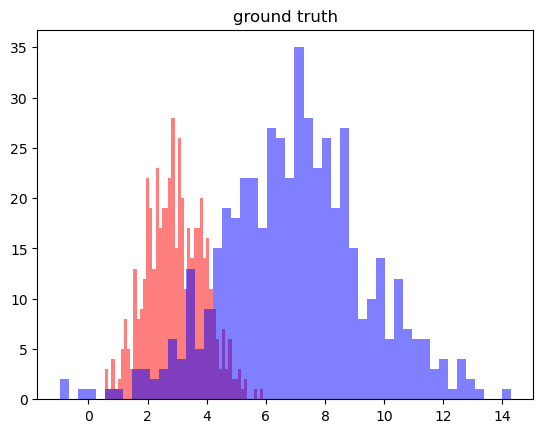

In [4]:
t1 = np.random.normal(mu1, sigma1, num)
plt.figure(0)
plt.hist(t1, bins= int(num/10), color='r', alpha=0.5)

t2 = np.random.normal(mu2, sigma2, num)
plt.hist(t2, bins= int(num / 10), color ='b', alpha=0.5) 

plt.title('ground truth') 

In [5]:
x = np.concatenate([t1, t2])
np.random.shuffle(x)

In [6]:
## EM algorithm
# assuming data come from 2 groups 
# make an initial guess of the mean and variance
mus = [0, 0.1]
stds = [0.5, 0.5]

In [7]:
def gaussian_prob(x, mu, std):
    y = 1/(np.sqrt(2*np.pi) * std) * np.exp(-(x-mu)**2/(2*std**2)) 
    return y 

def log_likelihood(likelihood_r, likelihood_b, r_i, b_i):
    ll = np.sum(np.log(np.multiply(r_i, likelihood_r) + np.multiply(b_i, likelihood_b)))
    return ll 

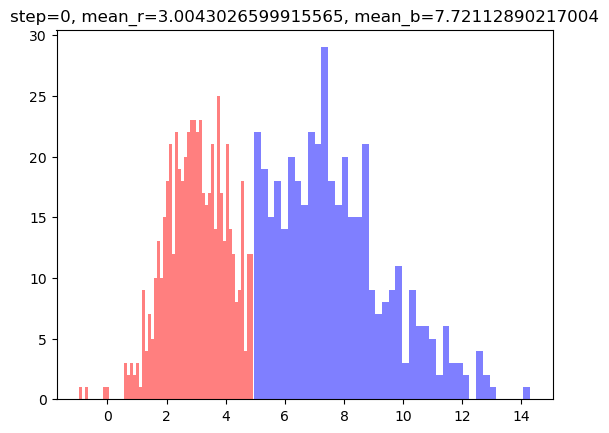

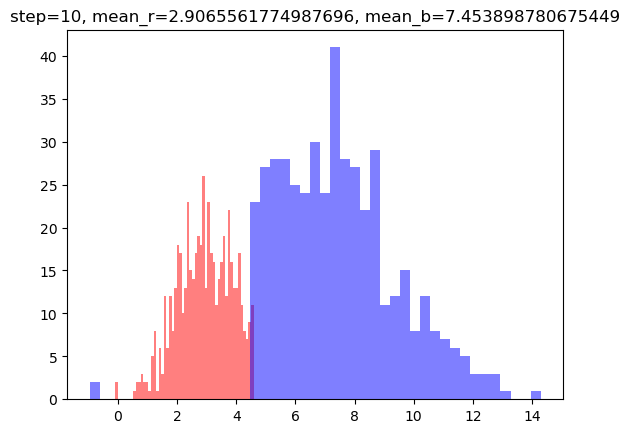

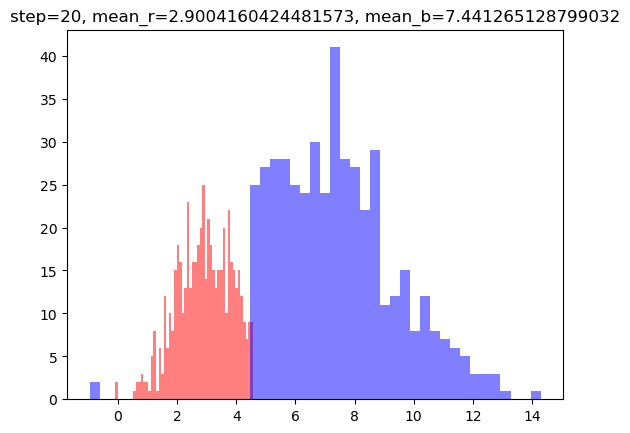

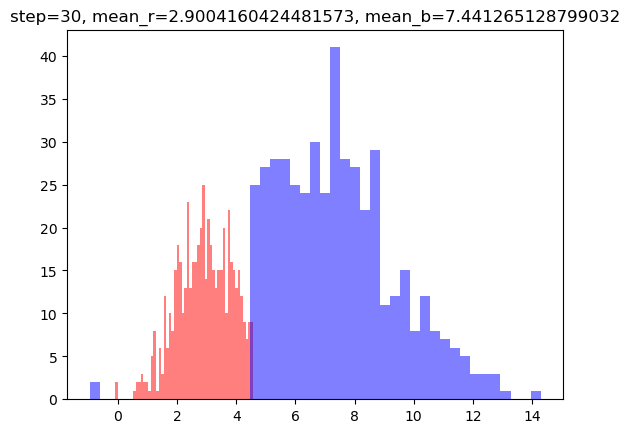

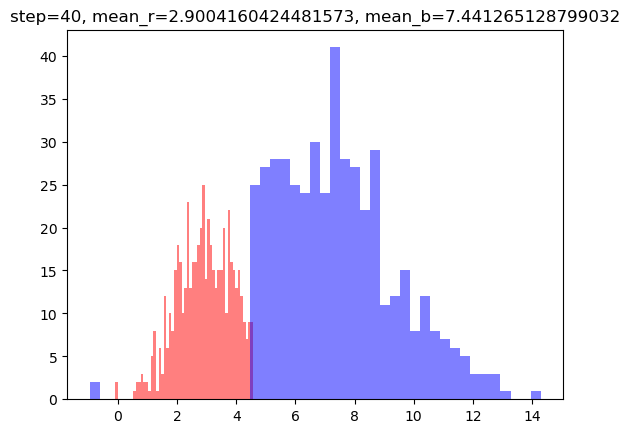

In [8]:
# set the maximum steps to iterate 
n_steps = 200

for step in np.arange(n_steps):
    # E step
    likelihood_r =  gaussian_prob(x, mus[0], stds[0]) 
    likelihood_b = gaussian_prob(x, mus[1], stds[1]) 
    
    b_i = np.divide(likelihood_b, (likelihood_b + likelihood_r)) 
    r_i = 1 - b_i

    ll_old = log_likelihood(likelihood_r, likelihood_b, r_i, b_i)

    # M step
    mu_b = np.dot(b_i, x) / np.sum(b_i) 
    mu_r = np.dot(r_i, x) / np.sum(r_i)

    sigma_b = np.dot(b_i, (x - mu_b)**2) / np.sum(b_i)
    sigma_r = np.dot(r_i, (x - mu_r)**2) / np.sum(r_i) 

    mus[0] = mu_r 
    mus[1] = mu_b 
    stds[0] = np.sqrt(sigma_r)
    stds[1] = np.sqrt(sigma_b)

    likelihood_r =  gaussian_prob(x, mus[0], stds[0]) 
    likelihood_b = gaussian_prob(x, mus[1], stds[1])

    b_i = np.divide(likelihood_b, (likelihood_b + likelihood_r)) 
    r_i = 1 - b_i

    # visualizing the decision on red/blue
    if np.mod(step, 10) == 0:
        x_r = x[r_i > b_i]
        x_b = np.setdiff1d(x, x_r) 
        plt.figure() 
        plt.hist(x_r, bins=int(len(x_r)/10), color='r', alpha=0.5) 
        plt.hist(x_b, bins=int(len(x_b)/10), color='b', alpha=0.5)  
        plt.title(f'step={step}, mean_r={np.mean(x_r)}, mean_b={np.mean(x_b)}')
        
    ll_new = log_likelihood(likelihood_r, likelihood_b, r_i, b_i)
    ll_diff = ll_new - ll_old

    if np.abs(ll_diff) < 1e-6:
        break 

In [9]:
mus 

[np.float64(2.9378110425914103), np.float64(6.93512498751821)]

In [10]:
stds 

[np.float64(0.9917441284717331), np.float64(2.418603523248371)]

In [11]:
step 

np.int64(42)